# 13. Risk Scoring — 위험 등급 분류 & SHAP 기여 요인

## 목적
XGBoost 최종 모델의 OOF 확률값을 **Low / Medium / High** 3단계 위험 등급으로 변환하고,  
SHAP 기반 기여 요인을 등급과 함께 출력합니다.

## 기획서 3.5.2 출력 기준
- 위험도 점수/구간: `low / medium / high`
- 기여 요인: lactate↑, BP↓, HR↑, WBC↑ 등 SHAP Top-3
- 행동 유도 메시지 (진단이 아닌 모니터링/확인 권고)

## 입력
- `DATA/processed/features_final.csv` (피처 only)
- `DATA/processed/labels_final.csv` (ID + 레이블)
- `DATA/processed/xgb_selected_features.csv`
- `DATA/models/xgb_final_models.pkl`
- `DATA/models/oof_prob.npy`

## 출력
- `DATA/processed/risk_thresholds.csv`
- `DATA/processed/risk_scored.csv`


In [1]:
from pathlib import Path
DATA_DIR    = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_DIR   = Path('..') / 'models'

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import roc_curve, confusion_matrix
import shap

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

TARGET = 'composite_next_24h'

print('=== 13. Risk Scoring — 위험 등급 분류 & SHAP 기여 요인 ===')


=== 13. Risk Scoring — 위험 등급 분류 & SHAP 기여 요인 ===


## Step 1: 데이터 & 모델 로드

> features_final.csv, labels_final.csv, xgb_selected_features.csv, xgb_final_models.pkl, oof_prob.npy 로드


In [2]:
print('Step 1: 데이터 & 모델 로드')

# features_final.csv 로드 (피처 only)
df_features = pd.read_csv(PROCESSED_DIR / 'features_final.csv')
df_labels = pd.read_csv(PROCESSED_DIR / 'labels_final.csv')
print(f'features_final: {len(df_features):,} rows, {df_features.columns.nunique()} cols')
print(f'labels_final: {len(df_labels):,} rows, {df_labels.columns.nunique()} cols')

assert len(df_features) == len(df_labels), 'features/labels row mismatch'

# 선정 피처 리스트 로드
selected_features = pd.read_csv(PROCESSED_DIR / 'xgb_selected_features.csv')['feature'].tolist()
print(f'선정 피처: {len(selected_features)}개')

# XGBoost 최종 모델 로드
with open(MODEL_DIR / 'xgb_final_models.pkl', 'rb') as f:
    models_final = pickle.load(f)
print(f'모델 Fold 수: {len(models_final)}')

# OOF 확률값 로드
oof_prob = np.load(MODEL_DIR / 'oof_prob.npy')
print(f'oof_prob shape: {oof_prob.shape}, min={oof_prob.min():.4f}, max={oof_prob.max():.4f}')

# 타겟 / stay_id / 피처 분리
y      = df_labels[TARGET].values
groups = df_labels['stay_id'].values
X      = df_features[selected_features]

print(f'\n타겟 분포 ({TARGET}):')
print(f'  0: {(y == 0).sum():,} ({(y == 0).mean()*100:.1f}%)')
print(f'  1: {(y == 1).sum():,} ({(y == 1).mean()*100:.1f}%)')
print('✔ 데이터 & 모델 로드 완료')


Step 1: 데이터 & 모델 로드
features_final: 158,985 rows, 53 cols
labels_final: 158,985 rows, 18 cols
선정 피처: 31개
모델 Fold 수: 5
oof_prob shape: (158985,), min=0.0007, max=0.9961

타겟 분포 (composite_next_24h):
  0: 145,985 (91.8%)
  1: 13,000 (8.2%)
✔ 데이터 & 모델 로드 완료


## Step 2: Threshold 결정 (3가지 방법 비교)

| 방법 | 설명 |
|------|------|
| **방법 1 — Youden's J** | `TPR - FPR` 최대화 지점 |
| **방법 2 — 민감도 우선** | Sensitivity ≥ 0.85 조건에서 Specificity 최대 |
| **방법 3 — 분위수 기반** | 상위 20% = High, 하위 50% = Low |

**최종 채택: 방법 2 (민감도 우선)** — 패혈증 악화를 놓치지 않는 것이 우선.


In [3]:
print('Step 2: Threshold 결정')

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y, oof_prob)

# ── 방법 1: Youden's J ──────────────────────────────────────────────────
J = tpr - fpr
idx_j = np.argmax(J)
thresh_youden = thresholds[idx_j]
sens_youden   = tpr[idx_j]
spec_youden   = 1 - fpr[idx_j]

# ── 방법 2: 민감도 우선 (sensitivity >= 0.85) ────────────────────────────
mask_sens = tpr >= 0.85
if mask_sens.any():
    # 민감도 충족 구간에서 specificity 최대 (fpr 최소)
    idx_s = np.where(mask_sens)[0]
    idx_sens = idx_s[np.argmin(fpr[idx_s])]
else:
    idx_sens = idx_j  # fallback
thresh_sens = thresholds[idx_sens]
sens_sens   = tpr[idx_sens]
spec_sens   = 1 - fpr[idx_sens]

# ── 방법 3: 분위수 기반 ─────────────────────────────────────────────────
thresh_q_low  = np.percentile(oof_prob, 50)   # 하위 50% = Low
thresh_q_high = np.percentile(oof_prob, 80)   # 상위 20% = High
# 방법 3 sensitivity / specificity (High threshold 기준)
pred_q = (oof_prob >= thresh_q_high).astype(int)
tp_q = ((pred_q == 1) & (y == 1)).sum()
fn_q = ((pred_q == 0) & (y == 1)).sum()
fp_q = ((pred_q == 1) & (y == 0)).sum()
tn_q = ((pred_q == 0) & (y == 0)).sum()
sens_q = tp_q / (tp_q + fn_q)
spec_q = tn_q / (tn_q + fp_q)

# ── 비교 표 ──────────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    '방법': ["Youden's J", '민감도 우선 (≥0.85)', '분위수 기반 (상위20%)'],
    'High Threshold': [thresh_youden, thresh_sens, thresh_q_high],
    'Sensitivity':    [sens_youden,   sens_sens,   sens_q],
    'Specificity':    [spec_youden,   spec_sens,   spec_q],
})
print('=== Threshold 비교 ===')
print(comparison.to_string(index=False, float_format='{:.4f}'.format))

# ── 최종 채택: 방법 2 ────────────────────────────────────────────────────
THRESH_HIGH = thresh_sens
THRESH_LOW  = THRESH_HIGH * 0.5  # Low/Medium 경계 = High threshold의 50%

print(f'\n=== 최종 채택: 민감도 우선 방식 ===')
print(f'  thresh_low  = {THRESH_LOW:.4f}  (< Low)')
print(f'  thresh_high = {THRESH_HIGH:.4f}  (>= High)')
print(f'  민감도: {sens_sens:.4f}, 특이도: {spec_sens:.4f}')

# ── 저장 ─────────────────────────────────────────────────────────────────
thresh_df = pd.DataFrame({
    'thresh_name': ['thresh_low', 'thresh_high'],
    'value':       [THRESH_LOW,    THRESH_HIGH],
})
thresh_df.to_csv(PROCESSED_DIR / 'risk_thresholds.csv', index=False)
print(f'\n✔ risk_thresholds.csv 저장 완료')
print(thresh_df.to_string(index=False))


Step 2: Threshold 결정
=== Threshold 비교 ===
            방법  High Threshold  Sensitivity  Specificity
    Youden's J          0.3960       0.7525       0.8807
민감도 우선 (≥0.85)          0.2018       0.8500       0.7675
분위수 기반 (상위20%)          0.3310       0.7799       0.8516

=== 최종 채택: 민감도 우선 방식 ===
  thresh_low  = 0.1009  (< Low)
  thresh_high = 0.2018  (>= High)
  민감도: 0.8500, 특이도: 0.7675

✔ risk_thresholds.csv 저장 완료
thresh_name    value
 thresh_low 0.100911
thresh_high 0.201821


## Step 3: 위험 등급 변환 함수

> OOF 확률값을 Low / Medium / High 3단계로 변환합니다.  
> 스칼라 및 배열 입력 모두 지원.


In [4]:
print('Step 3: 위험 등급 변환 함수')

def prob_to_risk_level(prob, thresh_low, thresh_high):
    """OOF 확률 → Low / Medium / High 위험 등급 변환.
    
    Parameters
    ----------
    prob        : float 또는 np.ndarray
    thresh_low  : Low/Medium 경계 (prob < thresh_low → 'Low')
    thresh_high : Medium/High 경계 (prob >= thresh_high → 'High')
    """
    scalar_input = np.isscalar(prob)
    arr = np.atleast_1d(np.asarray(prob, dtype=float))
    result = np.where(arr >= thresh_high, 'High',
             np.where(arr >= thresh_low,  'Medium', 'Low'))
    return result[0] if scalar_input else result

# 등급 변환 적용
risk_levels = prob_to_risk_level(oof_prob, THRESH_LOW, THRESH_HIGH)

# 분포 출력
print('\n=== 위험 등급 분포 ===')
for level in ['Low', 'Medium', 'High']:
    mask = risk_levels == level
    cnt  = mask.sum()
    pct  = mask.mean() * 100
    event_rate = y[mask].mean() if mask.sum() > 0 else 0
    print(f'  {level:6s}: {cnt:6,}개 ({pct:5.1f}%) | 실제 event율: {event_rate:.4f}')

print('\n✔ 위험 등급 변환 함수 정의 완료')


Step 3: 위험 등급 변환 함수

=== 위험 등급 분포 ===
  Low   : 93,578개 ( 58.9%) | 실제 event율: 0.0107
  Medium: 20,417개 ( 12.8%) | 실제 event율: 0.0464
  High  : 44,990개 ( 28.3%) | 실제 event율: 0.2456

✔ 위험 등급 변환 함수 정의 완료


## Step 4: SHAP 기여 요인 추출

> 마지막 Fold 모델로 전체 데이터 SHAP 계산.  
> 각 행별 SHAP 절대값 기준 Top-3 피처 추출, 방향(↑/↓) 표시.


In [15]:
print('Step 4: SHAP 기여 요인 추출')

import xgboost as xgb

# 마지막 fold 모델 사용
last_model = models_final[-1]
booster = last_model.get_booster() if hasattr(last_model, 'get_booster') else last_model

# 모델 피처 기준으로 SHAP 입력 구성
X_base = df_features if 'df_features' in globals() else X
if not isinstance(X_base, pd.DataFrame):
    X_base = pd.DataFrame(X_base, columns=selected_features)

model_features = getattr(booster, 'feature_names', None) or selected_features
missing = [f for f in model_features if f not in X_base.columns]
if missing:
    raise KeyError(f"모델 피처가 X에 없습니다: {missing[:5]}{'...' if len(missing) > 5 else ''}. features_final.csv를 확인하세요.")

X_shap = X_base[model_features]

# 샘플 제한 (5000개 이상이면 샘플링)
MAX_SHAP_SAMPLES = 5000
if len(X_shap) > MAX_SHAP_SAMPLES:
    print(f'샘플 수 {len(X_shap):,} > {MAX_SHAP_SAMPLES} → {MAX_SHAP_SAMPLES}개로 샘플링')
    X_shap = X_shap.sample(MAX_SHAP_SAMPLES, random_state=42)

explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_shap, check_additivity=False)   # shape: (n_rows, n_features)
print(f'SHAP values shape: {shap_values.shape}')

# 각 행별 Top-3 피처 추출
feature_arr = np.array(X_shap.columns)
abs_shap    = np.abs(shap_values)         # 절대값

# Top-3 인덱스 (내림차순)
top3_idx = np.argsort(abs_shap, axis=1)[:, -3:][:, ::-1]  # shape: (n_rows, 3)

# 방향: SHAP > 0 → '↑', < 0 → '↓'
shap_records = []
for i in range(len(X_shap)):
    row = {}
    for rank, col_idx in enumerate(top3_idx[i], start=1):
        feat = feature_arr[col_idx]
        direction = '↑' if shap_values[i, col_idx] > 0 else '↓'
        row[f'top{rank}_feature']   = feat
        row[f'top{rank}_direction'] = direction
        row[f'top{rank}_shap']      = shap_values[i, col_idx]
    shap_records.append(row)

df_shap = pd.DataFrame(shap_records, index=X_shap.index)
print(f'\nSHAP 기여 요인 DataFrame: {df_shap.shape}')
print(df_shap[['top1_feature','top1_direction','top2_feature','top2_direction',
               'top3_feature','top3_direction']].head(5).to_string(index=False))
print('\n✔ SHAP 기여 요인 추출 완료')


Step 4: SHAP 기여 요인 추출
샘플 수 158,985 > 5000 → 5000개로 샘플링
SHAP values shape: (5000, 51)

SHAP 기여 요인 DataFrame: (5000, 9)
    top1_feature top1_direction       top2_feature top2_direction     top3_feature top3_direction
      sofa_total              ↑   observation_hour              ↑               ph              ↓
      sofa_total              ↓          platelets              ↓ observation_hour              ↓
observation_hour              ↓         creatinine              ↑          lactate              ↓
      sofa_total              ↓         creatinine              ↓        platelets              ↑
      sofa_total              ↓ urine_ml_kg_hr_avg              ↓        platelets              ↓

✔ SHAP 기여 요인 추출 완료


## Step 5: 행동 유도 메시지 매핑

> 기획서 철학: **"우리는 진단하지 않는다"** — 모니터링/확인 권고 수준으로만 작성.


In [16]:
print('Step 5: 행동 유도 메시지 매핑')

ACTION_MAP = {
    'Low':    '정기 모니터링 유지',
    'Medium': '모니터링 강화 | 혈액배양 고려 | 바이탈 1시간마다 재확인',
    'High':   '즉시 담당의 통보 | 상급 처치 가능 여부 점검 | 전원 필요성 평가',
}

action_messages = np.array([ACTION_MAP[lvl] for lvl in risk_levels])

print('=== 행동 유도 메시지 예시 ===')
for level, msg in ACTION_MAP.items():
    print(f'  [{level:6s}] {msg}')

print('\n✔ 행동 유도 메시지 매핑 완료')


Step 5: 행동 유도 메시지 매핑
=== 행동 유도 메시지 예시 ===
  [Low   ] 정기 모니터링 유지
  [Medium] 모니터링 강화 | 혈액배양 고려 | 바이탈 1시간마다 재확인
  [High  ] 즉시 담당의 통보 | 상급 처치 가능 여부 점검 | 전원 필요성 평가

✔ 행동 유도 메시지 매핑 완료


## Step 6: 최종 출력 생성 & 저장

**출력 컬럼**: `stay_id, observation_hour, risk_prob, risk_level, action_message,`  
`top1_feature, top1_direction, top2_feature, top2_direction, top3_feature, top3_direction,`  
`composite_next_24h`


In [17]:
print('Step 6: 최종 출력 생성 & 저장')

# ID 컬럼 선택
id_cols_avail = [c for c in ['stay_id', 'observation_hour'] if c in df_labels.columns]

df_out = df_labels[id_cols_avail].copy()
df_out['risk_prob']      = oof_prob
df_out['risk_level']     = risk_levels
df_out['action_message'] = action_messages

# SHAP Top-3 컬럼 추가
shap_cols = ['top1_feature','top1_direction','top2_feature','top2_direction','top3_feature','top3_direction']
if len(df_shap) == len(df_out):
    for col in shap_cols:
        df_out[col] = df_shap[col].values
else:
    # 샘플링된 SHAP은 인덱스 기준으로 merge (미포함 행은 NaN)
    df_out = df_out.join(df_shap[shap_cols], how='left')

# 실제 레이블 추가
df_out[TARGET] = y

# 저장
out_path = PROCESSED_DIR / 'risk_scored.csv'
df_out.to_csv(out_path, index=False)

print(f'\n✔ risk_scored.csv 저장 완료: {out_path}')
print(f'   shape: {df_out.shape}')
print(df_out.head(5).to_string(index=False))


Step 6: 최종 출력 생성 & 저장

✔ risk_scored.csv 저장 완료: DATA/processed/risk_scored.csv
   shape: (158985, 12)
 stay_id  observation_hour  risk_prob risk_level action_message top1_feature top1_direction top2_feature top2_direction top3_feature top3_direction  composite_next_24h
30004242                 6   0.091924        Low     정기 모니터링 유지          NaN            NaN          NaN            NaN          NaN            NaN                   0
30004242                 7   0.060112        Low     정기 모니터링 유지          NaN            NaN          NaN            NaN          NaN            NaN                   0
30004242                 8   0.058571        Low     정기 모니터링 유지          NaN            NaN          NaN            NaN          NaN            NaN                   0
30004242                 9   0.063425        Low     정기 모니터링 유지          NaN            NaN          NaN            NaN          NaN            NaN                   0
30004242                10   0.056951        Low     정기 모니

## Step 7: 시각화

1. 확률 분포 히스토그램 (Low/Medium/High 영역 색상 구분)
2. 등급별 실제 event율 막대그래프
3. 시간별(observation_hour) 위험 등급 분포 누적 면적 그래프
4. High 등급 환자의 Top 기여 요인 빈도 막대그래프


Step 7: 시각화


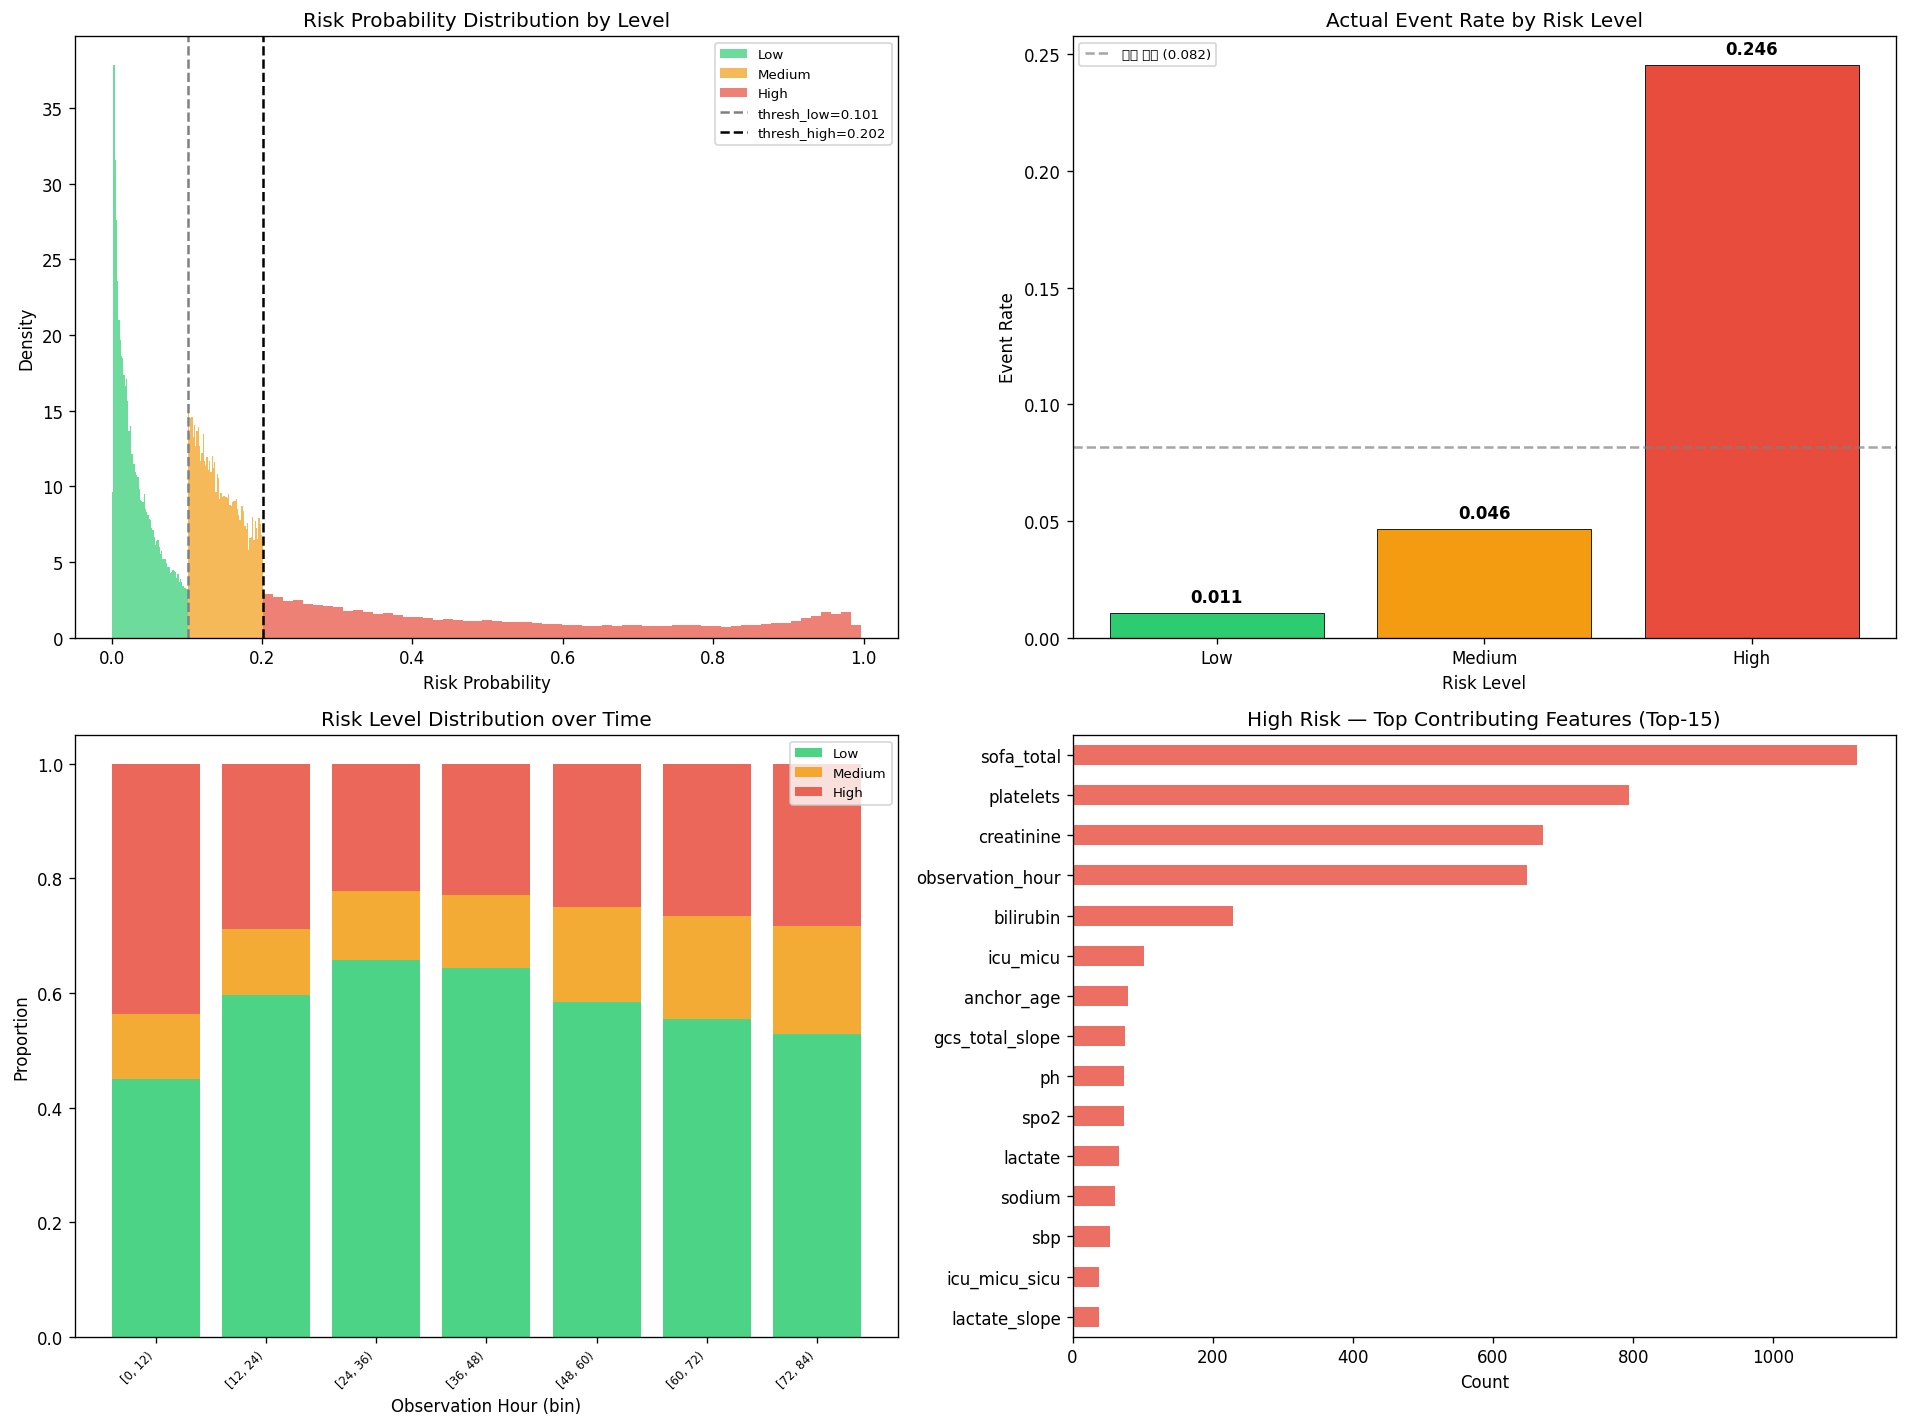


✔ 시각화 완료


In [18]:
print('Step 7: 시각화')

COLORS = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 1. 확률 분포 히스토그램 ───────────────────────────────────────────────
ax = axes[0, 0]
ax.hist(oof_prob[risk_levels == 'Low'],    bins=60, alpha=0.7,
        color=COLORS['Low'],    label='Low',    density=True)
ax.hist(oof_prob[risk_levels == 'Medium'], bins=60, alpha=0.7,
        color=COLORS['Medium'], label='Medium', density=True)
ax.hist(oof_prob[risk_levels == 'High'],   bins=60, alpha=0.7,
        color=COLORS['High'],   label='High',   density=True)
ax.axvline(THRESH_LOW,  color='gray',   linestyle='--', lw=1.5,
           label=f'thresh_low={THRESH_LOW:.3f}')
ax.axvline(THRESH_HIGH, color='black',  linestyle='--', lw=1.5,
           label=f'thresh_high={THRESH_HIGH:.3f}')
ax.set_xlabel('Risk Probability')
ax.set_ylabel('Density')
ax.set_title('Risk Probability Distribution by Level')
ax.legend(fontsize=8)

# ── 2. 등급별 실제 event율 ───────────────────────────────────────────────
ax = axes[0, 1]
levels_order = ['Low', 'Medium', 'High']
event_rates  = [y[risk_levels == lvl].mean() for lvl in levels_order]
bars = ax.bar(levels_order, event_rates,
              color=[COLORS[l] for l in levels_order], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, event_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.axhline(y.mean(), color='gray', linestyle='--', alpha=0.7,
           label=f'전체 평균 ({y.mean():.3f})')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Event Rate')
ax.set_title('Actual Event Rate by Risk Level')
ax.legend(fontsize=8)

# ── 3. 시간별 위험 등급 분포 (누적 면적) ────────────────────────────────
ax = axes[1, 0]
if 'observation_hour' in df_out.columns:
    df_time = df_out.copy()
    df_time['hour_bin'] = pd.cut(df_time['observation_hour'],
                                  bins=range(0, int(df_time['observation_hour'].max())+13, 12),
                                  right=False)
    pivot = df_time.groupby('hour_bin')['risk_level'].value_counts(normalize=True).unstack(fill_value=0)
    # 컬럼 순서 보장
    for lvl in levels_order:
        if lvl not in pivot.columns:
            pivot[lvl] = 0
    pivot = pivot[levels_order]
    x_labels = [str(b) for b in pivot.index]
    x_pos    = range(len(pivot))
    bottom   = np.zeros(len(pivot))
    for lvl in levels_order:
        ax.bar(x_pos, pivot[lvl].values, bottom=bottom,
               color=COLORS[lvl], label=lvl, alpha=0.85)
        bottom += pivot[lvl].values
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=7)
    ax.set_xlabel('Observation Hour (bin)')
    ax.set_ylabel('Proportion')
    ax.set_title('Risk Level Distribution over Time')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'observation_hour 없음', ha='center', va='center',
            transform=ax.transAxes)

# ── 4. High 등급 Top 기여 요인 빈도 ──────────────────────────────────────
ax = axes[1, 1]
high_mask = risk_levels == 'High'
feature_cols_top = ['top1_feature','top2_feature','top3_feature']
df_high = df_out.loc[high_mask, feature_cols_top].dropna(how='all')

# top1~3 피처를 모두 수집
factor_counts = pd.concat([
    df_high['top1_feature'],
    df_high['top2_feature'],
    df_high['top3_feature'],
]).value_counts().head(15)

factor_counts.iloc[::-1].plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8)
ax.set_xlabel('Count')
ax.set_title('High Risk — Top Contributing Features (Top-15)')

plt.tight_layout()
plt.show()
print('\n✔ 시각화 완료')


## Step 8: 성능 검증 요약 출력

> High 등급의 Sensitivity(민감도)와 Precision(정밀도)을 확인합니다.


In [19]:
print('Step 8: 성능 검증 요약')

# 등급별 통계
level_stats = []
for lvl in ['Low', 'Medium', 'High']:
    mask = risk_levels == lvl
    cnt  = mask.sum()
    pct  = mask.mean() * 100
    er   = y[mask].mean() if cnt > 0 else 0
    level_stats.append({'level': lvl, 'count': cnt, 'pct': pct, 'event_rate': er})

# High 등급 Sensitivity / Precision
high_mask = risk_levels == 'High'
tp_h  = ((high_mask) & (y == 1)).sum()
fn_h  = ((~high_mask) & (y == 1)).sum()
fp_h  = ((high_mask) & (y == 0)).sum()
sens_h = tp_h / (tp_h + fn_h) if (tp_h + fn_h) > 0 else 0
prec_h = tp_h / (tp_h + fp_h) if (tp_h + fp_h) > 0 else 0

print('\n' + '='*50)
print('=== Risk Scoring 검증 요약 ===')
print('='*50)
print(f'threshold_low  : {THRESH_LOW:.4f}')
print(f'threshold_high : {THRESH_HIGH:.4f}')
print(f'\n등급별 분포:')
for stat in level_stats:
    print(f'  {stat["level"]:6s}: {stat["count"]:6,}개 ({stat["pct"]:5.1f}%) | event율: {stat["event_rate"]:.4f}')
print(f'\nHigh 등급 sensitivity : {sens_h:.4f}  (High로 잡은 실제 event 비율)')
print(f'High 등급 precision   : {prec_h:.4f}  (High 중 실제 event 비율)')
print('='*50)

# 출력 파일 확인
print('\n=== 저장된 파일 ===')
for fpath in [PROCESSED_DIR / 'risk_thresholds.csv', PROCESSED_DIR / 'risk_scored.csv']:
    tmp = pd.read_csv(fpath)
    print(f'  {fpath.name}: {len(tmp):,} rows, {len(tmp.columns)} cols')
    print(f'    {tmp.head(2).to_string(index=False)}')
    print()

print('\n✔ 13. Risk Scoring 완료')


Step 8: 성능 검증 요약

=== Risk Scoring 검증 요약 ===
threshold_low  : 0.1009
threshold_high : 0.2018

등급별 분포:
  Low   : 93,578개 ( 58.9%) | event율: 0.0107
  Medium: 20,417개 ( 12.8%) | event율: 0.0464
  High  : 44,990개 ( 28.3%) | event율: 0.2456

High 등급 sensitivity : 0.8500  (High로 잡은 실제 event 비율)
High 등급 precision   : 0.2456  (High 중 실제 event 비율)

=== 저장된 파일 ===
  risk_thresholds.csv: 2 rows, 2 cols
    thresh_name    value
 thresh_low 0.100911
thresh_high 0.201821

  risk_scored.csv: 158,985 rows, 12 cols
     stay_id  observation_hour  risk_prob risk_level action_message top1_feature top1_direction top2_feature top2_direction top3_feature top3_direction  composite_next_24h
30004242                 6   0.091924        Low     정기 모니터링 유지          NaN            NaN          NaN            NaN          NaN            NaN                   0
30004242                 7   0.060112        Low     정기 모니터링 유지          NaN            NaN          NaN            NaN          NaN            NaN           